In [1]:
# ============================================================================
# COMPLETE SCRIPT: FETCH 1-YEAR IPO RETURNS
# ============================================================================

# Install yfinance if needed (run this once in a cell first):
# !pip install yfinance

# All imports
import yfinance as yf
import pandas as pd
import time
from datetime import datetime, timedelta
import warnings
import gc

# Suppress warnings
warnings.filterwarnings('ignore')

# ============================================================================
# FUNCTION TO GET 1-YEAR RETURN
# ============================================================================

def get_1year_return_yfinance(ticker, ipo_date, offer_price):
    """Get 1-year return using Yahoo Finance"""
    try:
        ipo_dt = pd.to_datetime(ipo_date)
        one_year_later = ipo_dt + timedelta(days=365)
        end_date = one_year_later + timedelta(days=7)
        
        stock = yf.Ticker(ticker)
        hist = stock.history(start=one_year_later.strftime('%Y-%m-%d'), 
                            end=end_date.strftime('%Y-%m-%d'))
        
        if len(hist) > 0:
            price_1yr = hist['Close'].iloc[0]
            actual_date = hist.index[0]
            
            if actual_date.tzinfo is not None:
                actual_date = actual_date.tz_localize(None)
            
            return_pct = ((price_1yr - offer_price) / offer_price) * 100
            return_binary = 1 if return_pct > 0 else 0
            days_from_ipo = (actual_date - ipo_dt).days
            
            return {
                'price_1yr': round(price_1yr, 2),
                'return_pct': round(return_pct, 2),
                'return_binary': return_binary,
                'actual_date': actual_date.strftime('%Y-%m-%d'),
                'days_from_ipo': days_from_ipo,
                'status': 'success'
            }
        else:
            return {
                'price_1yr': None,
                'return_pct': None,
                'return_binary': None,
                'actual_date': None,
                'days_from_ipo': None,
                'status': 'no_data'
            }
            
    except Exception as e:
        return {
            'price_1yr': None,
            'return_pct': None,
            'return_binary': None,
            'actual_date': None,
            'days_from_ipo': None,
            'status': 'no_data'
        }

# ============================================================================
# MAIN PROCESSING - FRESH START
# ============================================================================

print("="*80)
print("FETCHING 1-YEAR RETURNS - COMPLETE SCRIPT")
print("="*80 + "\n")

# Load data
df = pd.read_csv('data.csv')

# Initialize all columns
df['price_1yr'] = None
df['1_year_return'] = None
df['1_year_up'] = None
df['actual_date_1yr'] = None
df['days_from_ipo'] = None
df['status'] = None

# Mark first 63 rows as skipped (CUSIPs)
df.loc[:62, 'status'] = 'skipped_cusip'

print(f"Total IPOs: {len(df)}")
print(f"Skipping rows 1-63 (CUSIPs)")
print(f"Processing rows 64-1700 ({len(df)-63} IPOs)\n")

# Counters
success = 0
no_data = 0
batch_count = 0

# Process from row 63 onwards
for idx in range(63, len(df)):
    row = df.iloc[idx]
    ticker = str(row['Issuer Ticker']).strip()
    company_name = row['Issuer Name']
    ipo_date = row['Trade Date (US)']
    offer_price = row['Offer Price']
    
    print(f"[{idx+1}/{len(df)}] {ticker:6s} - {company_name[:35]}")
    print(f"    IPO: {ipo_date} | ${offer_price:.2f}...", end=' ')
    
    # Get 1-year return
    result = get_1year_return_yfinance(ticker, ipo_date, offer_price)
    
    # Store results
    df.at[idx, 'price_1yr'] = result['price_1yr']
    df.at[idx, '1_year_return'] = result['return_pct']
    df.at[idx, '1_year_up'] = result['return_binary']
    df.at[idx, 'actual_date_1yr'] = result['actual_date']
    df.at[idx, 'days_from_ipo'] = result['days_from_ipo']
    df.at[idx, 'status'] = result['status']
    
    # Report result
    if result['status'] == 'success':
        print(f"✓ {result['return_pct']:+.2f}%")
        success += 1
    else:
        print(f"❌ No data")
        no_data += 1
    
    batch_count += 1
    
    # Save every 10 stocks and clear memory
    if batch_count % 10 == 0:
        df.to_csv('data_with_1year_PROGRESS.csv', index=False)
        print(f"  💾 Saved | ✓{success} ❌{no_data}\n")
        gc.collect()
    
    time.sleep(0.3)

# ============================================================================
# SAVE FINAL RESULTS
# ============================================================================

output_file = 'data_with_1year_returns_FINAL.csv'
df.to_csv(output_file, index=False)

print("\n" + "="*80)
print("PROCESSING COMPLETE!")
print("="*80)
print(f"✓ Successful: {success}")
print(f"❌ No data: {no_data}")
print(f"Total processed: {success + no_data}")

print(f"\n✓ Saved to: {output_file}")

# ============================================================================
# FINAL STATISTICS
# ============================================================================

completed = df[df['status'] == 'success']
total_with_data = len(completed)

if total_with_data > 0:
    print("\n" + "="*80)
    print(f"FINAL STATISTICS ({total_with_data} IPOs)")
    print("="*80)
    
    positive = (completed['1_year_up'] == 1).sum()
    negative = (completed['1_year_up'] == 0).sum()
    
    print(f"\n📊 Distribution:")
    print(f"   Positive returns: {positive} ({positive/total_with_data*100:.1f}%)")
    print(f"   Negative returns: {negative} ({negative/total_with_data*100:.1f}%)")
    
    print(f"\n📈 Return Statistics:")
    print(f"   Mean:   {completed['1_year_return'].mean():+.2f}%")
    print(f"   Median: {completed['1_year_return'].median():+.2f}%")
    print(f"   Std:    {completed['1_year_return'].std():.2f}%")
    print(f"   Min:    {completed['1_year_return'].min():+.2f}%")
    print(f"   Max:    {completed['1_year_return'].max():+.2f}%")
    
    if total_with_data >= 5:
        print(f"\n🏆 Top 5 Best Performers:")
        top5 = completed.nlargest(5, '1_year_return')[['Issuer Ticker', 'Issuer Name', '1_year_return']]
        for _, r in top5.iterrows():
            print(f"   {r['Issuer Ticker']:6s} {r['Issuer Name'][:45]:45s} {r['1_year_return']:+7.2f}%")
        
        print(f"\n📉 Top 5 Worst Performers:")
        bottom5 = completed.nsmallest(5, '1_year_return')[['Issuer Ticker', 'Issuer Name', '1_year_return']]
        for _, r in bottom5.iterrows():
            print(f"   {r['Issuer Ticker']:6s} {r['Issuer Name'][:45]:45s} {r['1_year_return']:+7.2f}%")
    
    # Compare to 1st day
    print(f"\n📊 1st Day vs 1-Year Comparison:")
    df_tickers = df.iloc[63:]
    first_day_up = (df_tickers['Underpriced'] == 1).sum()
    first_day_total = len(df_tickers)
    print(f"   1st Day Up:  {first_day_up}/{first_day_total} ({first_day_up/first_day_total*100:.1f}%)")
    print(f"   1-Year Up:   {positive}/{total_with_data} ({positive/total_with_data*100:.1f}%)")

print("\n" + "="*80)
print("✅ ALL DONE!")
print("="*80)

FETCHING 1-YEAR RETURNS - COMPLETE SCRIPT

Total IPOs: 1700
Skipping rows 1-63 (CUSIPs)
Processing rows 64-1700 (1637 IPOs)

[64/1700] AACH   - AAC Holdings Inc
    IPO: 10/2/14 | $15.00... 

$AACH: possibly delisted; no timezone found


❌ No data
[65/1700] AAOI   - Applied Optoelectronics Inc
    IPO: 9/26/13 | $10.00... ✓ +68.10%
[66/1700] AAT    - American Assets Trust Inc
    IPO: 1/13/11 | $20.50... ✓ -38.02%
[67/1700] ABG    - Asbury Automotive Group Inc
    IPO: 3/14/02 | $16.50... ✓ -66.52%
[68/1700] ABNB   - Airbnb Inc
    IPO: 12/10/20 | $68.00... ✓ +165.32%
[69/1700] ABR    - Arbor Realty Trust Inc
    IPO: 4/7/04 | $20.00... ✓ -76.97%
[70/1700] ABTX   - Allegiance Bancshares Inc
    IPO: 10/8/15 | $21.00... 

$ABTX: possibly delisted; no timezone found


❌ No data
[71/1700] ACAD   - ACADIA Pharmaceuticals Inc
    IPO: 5/27/04 | $7.00... ✓ +23.57%
[72/1700] ACC    - American Campus Communities In
    IPO: 8/12/04 | $17.50... 

...

❌ No data
[77/1700] ACLS   - Axcelis Technologies Inc
    IPO: 7/11/00 | $22.00... ✓ +136.18%
[78/1700] ACM    - AECOM
    IPO: 5/10/07 | $20.00... ✓ +42.73%
[79/1700] ACMR   - ACM Research Inc
    IPO: 11/3/17 | $5.60... ✓ -40.54%
[80/1700] ACOR   - Acorda Therapeutics Inc
    IPO: 2/10/06 | $6.00... 

$ACOR: possibly delisted; no timezone found


❌ No data
[81/1700] ACRE   - Ares Commercial Real Estate Co
    IPO: 4/26/12 | $18.50... ✓ -74.78%
[82/1700] ACRS   - Aclaris Therapeutics Inc
    IPO: 10/7/15 | $11.00... ✓ +123.82%
[83/1700] ACRX   - AcelRx Pharmaceuticals Inc
    IPO: 2/11/11 | $5.00... 

$ACRX: possibly delisted; no timezone found


❌ No data
  💾 Saved | ✓13 ❌7



In [ ]:
# ============================================================================
# FIX: FORCE PROCESS FROM 674
# ============================================================================

import yfinance as yf
import pandas as pd
import time
from datetime import datetime, timedelta
import warnings
import gc

warnings.filterwarnings('ignore')

def get_1year_return_yfinance(ticker, ipo_date, offer_price):
    """Get 1-year return using Yahoo Finance"""
    try:
        ipo_dt = pd.to_datetime(ipo_date)
        one_year_later = ipo_dt + timedelta(days=365)
        end_date = one_year_later + timedelta(days=7)
        
        stock = yf.Ticker(ticker)
        hist = stock.history(start=one_year_later.strftime('%Y-%m-%d'), 
                            end=end_date.strftime('%Y-%m-%d'))
        
        if len(hist) > 0:
            price_1yr = hist['Close'].iloc[0]
            actual_date = hist.index[0]
            
            if actual_date.tzinfo is not None:
                actual_date = actual_date.tz_localize(None)
            
            return_pct = ((price_1yr - offer_price) / offer_price) * 100
            return_binary = 1 if return_pct > 0 else 0
            days_from_ipo = (actual_date - ipo_dt).days
            
            return {
                'price_1yr': round(price_1yr, 2),
                'return_pct': round(return_pct, 2),
                'return_binary': return_binary,
                'actual_date': actual_date.strftime('%Y-%m-%d'),
                'days_from_ipo': days_from_ipo,
                'status': 'success'
            }
        else:
            return {
                'price_1yr': None,
                'return_pct': None,
                'return_binary': None,
                'actual_date': None,
                'days_from_ipo': None,
                'status': 'no_data'
            }
            
    except Exception as e:
        return {
            'price_1yr': None,
            'return_pct': None,
            'return_binary': None,
            'actual_date': None,
            'days_from_ipo': None,
            'status': 'no_data'
        }

# ============================================================================
# FORCE PROCESS FROM 674 - NO SKIP CHECK
# ============================================================================

print("="*80)
print("FORCE PROCESS FROM 674 - OVERWRITE EVERYTHING")
print("="*80 + "\n")

# Load progress
df = pd.read_csv('data_with_1year_PROGRESS.csv')

print(f"Starting from row 674")
print(f"Will process rows 674-1700 (except 681 and 1291)\n")

# Skip only these specific crash-causing rows
SKIP_INDICES = [680, 1290]  # Rows 681 and 1291

# Counters
success = 0
no_data = 0
skipped = 0
batch_count = 0

# Start from 674 (index 673)
for idx in range(673, len(df)):
    # Skip crash-causing rows ONLY
    if idx in SKIP_INDICES:
        df.at[idx, 'status'] = 'skipped_crash'
        df.at[idx, 'price_1yr'] = None
        df.at[idx, '1_year_return'] = None
        df.at[idx, '1_year_up'] = None
        ticker = df.iloc[idx]['Issuer Ticker']
        print(f"[{idx+1}/{len(df)}] {ticker:6s} - ⏭️  SKIPPED (causes crash)\n")
        skipped += 1
        df.to_csv('data_with_1year_PROGRESS.csv', index=False)
        continue
    
    # Process EVERY other row (no skip check)
    row = df.iloc[idx]
    ticker = str(row['Issuer Ticker']).strip()
    company_name = row['Issuer Name']
    ipo_date = row['Trade Date (US)']
    offer_price = row['Offer Price']
    
    print(f"[{idx+1}/{len(df)}] {ticker:6s} - {company_name[:35]}")
    print(f"    ${offer_price:.2f}...", end=' ')
    
    # Get 1-year return
    result = get_1year_return_yfinance(ticker, ipo_date, offer_price)
    
    # Store results
    df.at[idx, 'price_1yr'] = result['price_1yr']
    df.at[idx, '1_year_return'] = result['return_pct']
    df.at[idx, '1_year_up'] = result['return_binary']
    df.at[idx, 'actual_date_1yr'] = result['actual_date']
    df.at[idx, 'days_from_ipo'] = result['days_from_ipo']
    df.at[idx, 'status'] = result['status']
    
    # Report
    if result['status'] == 'success':
        print(f"✓ {result['return_pct']:+.2f}%")
        success += 1
    else:
        print(f"❌")
        no_data += 1
    
    batch_count += 1
    
    # Save every 5
    if batch_count % 5 == 0:
        df.to_csv('data_with_1year_PROGRESS.csv', index=False)
        print(f"  💾 | ✓{success} ❌{no_data}\n")
        gc.collect()
    
    time.sleep(0.3)

# Final save
df.to_csv('data_with_1year_returns_FINAL.csv', index=False)

print(f"\n✓ Success: {success} | ❌ No data: {no_data}")

FORCE PROCESS FROM 674 - OVERWRITE EVERYTHING

Starting from row 674
Will process rows 674-1700 (except 681 and 1291)

[674/1700] GOOD   - Gladstone Commercial Corp
    $15.00... ✓ -82.15%
[675/1700] GOOGL  - Alphabet Inc
    $85.00... ✓ -91.81%
[676/1700] GPMT   - Granite Point Mortgage Trust I
    $19.50... ✓ -53.12%
[677/1700] GPP    - Green Plains Partners LP
    $15.00... 

$GPP: possibly delisted; no timezone found


❌
[678/1700] GPRO   - GoPro Inc
    $24.00... ✓ +125.54%
  💾 | ✓4 ❌1

[679/1700] GRBK   - Green Brick Partners Inc
    $10.50... ✓ +287.91%
[680/1700] GRPN   - Groupon Inc
    $20.00... ✓ +290.00%
[681/1700] GRTS   - ⏭️  SKIPPED (causes crash)

[682/1700] GSAT   - Globalstar Inc
    $17.00... ✓ +635.88%
[683/1700] GSBD   - Goldman Sachs BDC Inc
    $20.00... ✓ -65.17%
[684/1700] GSHD   - Goosehead Insurance Inc
    $10.00... ✓ +174.22%
  💾 | ✓9 ❌1

[685/1700] GSHTU  - Verra Mobility Corp
    $10.00... ✓ +4.60%
[686/1700] GSIT   - GSI Technology Inc
    $5.50... ✓ -49.82%
[687/1700] GSKY   - GreenSky Inc
    $23.00... 

$GSKY: possibly delisted; no timezone found


❌
[688/1700] GTES   - Gates Industrial Corp PLC
    $19.00... ✓ -23.42%
[689/1700] GTHX   - G1 Therapeutics Inc
    $15.00... 

...

$UBNK: possibly delisted; no timezone found


❌
[1557/1700] UCP    - UCP Inc
    $15.00... 

$UCP: possibly delisted; no price data found  (1d 2014-07-18 -> 2014-07-25) (Yahoo error = "Data doesn't exist for startDate = 1405656000, endDate = 1406260800")


❌
[1558/1700] UCTT   - Ultra Clean Holdings Inc
    $7.00... ✓ -12.29%


KeyboardInterrupt: 

In [ ]:
# ============================================================================
# RESUME FROM 1290
# ============================================================================

import yfinance as yf
import pandas as pd
import time
from datetime import datetime, timedelta
import warnings
import gc

warnings.filterwarnings('ignore')

def get_1year_return_yfinance(ticker, ipo_date, offer_price):
    """Get 1-year return using Yahoo Finance"""
    try:
        ipo_dt = pd.to_datetime(ipo_date)
        one_year_later = ipo_dt + timedelta(days=365)
        end_date = one_year_later + timedelta(days=7)
        
        stock = yf.Ticker(ticker)
        hist = stock.history(start=one_year_later.strftime('%Y-%m-%d'), 
                            end=end_date.strftime('%Y-%m-%d'))
        
        if len(hist) > 0:
            price_1yr = hist['Close'].iloc[0]
            actual_date = hist.index[0]
            
            if actual_date.tzinfo is not None:
                actual_date = actual_date.tz_localize(None)
            
            return_pct = ((price_1yr - offer_price) / offer_price) * 100
            return_binary = 1 if return_pct > 0 else 0
            days_from_ipo = (actual_date - ipo_dt).days
            
            return {
                'price_1yr': round(price_1yr, 2),
                'return_pct': round(return_pct, 2),
                'return_binary': return_binary,
                'actual_date': actual_date.strftime('%Y-%m-%d'),
                'days_from_ipo': days_from_ipo,
                'status': 'success'
            }
        else:
            return {
                'price_1yr': None,
                'return_pct': None,
                'return_binary': None,
                'actual_date': None,
                'days_from_ipo': None,
                'status': 'no_data'
            }
            
    except Exception as e:
        return {
            'price_1yr': None,
            'return_pct': None,
            'return_binary': None,
            'actual_date': None,
            'days_from_ipo': None,
            'status': 'no_data'
        }

# ============================================================================
# RESUME FROM 1290
# ============================================================================

print("="*80)
print("RESUME FROM 1290")
print("="*80 + "\n")

df = pd.read_csv('data_with_1year_PROGRESS.csv')

print(f"Starting from row 1290")
print(f"Remaining: {len(df) - 1289} rows\n")

# Skip rows that cause crashes
SKIP_INDICES = [680, 1290, 1293]  # 681, 1291, 1294

success = 0
no_data = 0
skipped = 0
batch_count = 0

# Start from 1290 (index 1289)
for idx in range(1289, len(df)):
    # Skip crash rows
    if idx in SKIP_INDICES:
        df.at[idx, 'status'] = 'skipped_crash'
        ticker = df.iloc[idx]['Issuer Ticker']
        print(f"[{idx+1}/{len(df)}] {ticker:6s} - ⏭️  SKIPPED\n")
        skipped += 1
        df.to_csv('data_with_1year_PROGRESS.csv', index=False)
        continue
    
    row = df.iloc[idx]
    ticker = str(row['Issuer Ticker']).strip()
    company_name = row['Issuer Name']
    ipo_date = row['Trade Date (US)']
    offer_price = row['Offer Price']
    
    print(f"[{idx+1}/{len(df)}] {ticker:6s} - {company_name[:30]}")
    print(f"    ${offer_price:.2f}...", end=' ')
    
    result = get_1year_return_yfinance(ticker, ipo_date, offer_price)
    
    df.at[idx, 'price_1yr'] = result['price_1yr']
    df.at[idx, '1_year_return'] = result['return_pct']
    df.at[idx, '1_year_up'] = result['return_binary']
    df.at[idx, 'actual_date_1yr'] = result['actual_date']
    df.at[idx, 'days_from_ipo'] = result['days_from_ipo']
    df.at[idx, 'status'] = result['status']
    
    if result['status'] == 'success':
        print(f"✓ {result['return_pct']:+.2f}%")
        success += 1
    else:
        print(f"❌")
        no_data += 1
    
    batch_count += 1
    
    if batch_count % 5 == 0:
        df.to_csv('data_with_1year_PROGRESS.csv', index=False)
        print(f"  💾 | ✓{success} ❌{no_data}\n")
        gc.collect()
    
    time.sleep(0.3)

df.to_csv('data_with_1year_returns_FINAL.csv', index=False)

print(f"\n✅ Done! ✓{success} ❌{no_data}")

RESUME FROM 1290

Starting from row 1290
Remaining: 411 rows

[1290/1700] RNDB   - Randolph Bancorp Inc
    $10.00... 

$RNDB: possibly delisted; no timezone found


❌
[1291/1700] RNET   - ⏭️  SKIPPED

[1292/1700] RNG    - RingCentral Inc
    $13.00... ✓ -2.69%
[1293/1700] RNGR   - Ranger Energy Services Inc
    $14.50... ✓ -39.78%


$ROKA: possibly delisted; no price data found  (1d 2015-07-17 -> 2015-07-24)


[1294/1700] ROAD   - ⏭️  SKIPPED

[1295/1700] ROKA   - Sorrento Tech Inc
    $12.00... ❌
[1296/1700] ROKU   - Roku Inc
    $14.00... ✓ +421.64%
  💾 | ✓3 ❌2

[1297/1700] ROOT   - Root Inc/OH
    $27.00... ✓ +221.33%
[1298/1700] ROX    - Castle Brands Inc
    $9.00... 

...

❌
[1694/1700] ZOES   - Zoe's Kitchen Inc
    $15.00... ✓ +130.40%
[1695/1700] ZS     - Zscaler Inc
    $16.00... ✓ +320.50%
[1696/1700] ZSANQ  - Zosano Pharma Corp
    $11.00... 

$ZSANQ: possibly delisted; no timezone found


❌
  💾 | ✓219 ❌186

[1697/1700] ZTS    - Zoetis Inc
    $26.00... ✓ +6.88%
[1698/1700] ZUMZ   - Zumiez Inc
    $18.00... ✓ +87.50%
[1699/1700] ZUO    - Zuora Inc
    $14.00... 

$ZUO: possibly delisted; no timezone found


❌
[1700/1700] ZWS    - Zurn Elkay Water Solutions Cor
    $18.00... ✓ -47.87%

✅ Done! ✓222 ❌187


In [ ]:
import pandas as pd
import requests
import time

# Your Alpha Vantage API key
API_KEY = '8TFX70M1HR76F2KE'

def check_nasdaq_alpha_vantage(ticker, api_key):
    """
    Check if ticker has data on Alpha Vantage (which uses Nasdaq data)
    """
    url = f'https://www.alphavantage.co/query?function=OVERVIEW&symbol={ticker}&apikey={api_key}'
    
    try:
        response = requests.get(url)
        data = response.json()
        
        # Check if we got actual company data
        if 'Symbol' in data and data['Symbol'] == ticker:
            return {
                'has_data': True,
                'name': data.get('Name', 'N/A'),
                'exchange': data.get('Exchange', 'N/A'),
                'status': data.get('Status', 'N/A')
            }
        elif 'Note' in data:
            return {'has_data': False, 'reason': 'rate_limit'}
        else:
            return {'has_data': False, 'reason': 'no_data'}
            
    except Exception as e:
        return {'has_data': False, 'reason': f'error: {str(e)}'}

def check_nasdaq_time_series(ticker, ipo_date, api_key):
    """
    Check if ticker has historical time series data
    """
    from datetime import datetime, timedelta
    
    ipo_dt = pd.to_datetime(ipo_date)
    one_year_later = ipo_dt + timedelta(days=365)
    
    url = f'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol={ticker}&apikey={api_key}&outputsize=compact'
    
    try:
        response = requests.get(url)
        data = response.json()
        
        if 'Time Series (Daily)' in data:
            time_series = data['Time Series (Daily)']
            dates = list(time_series.keys())
            
            # Check if we have data around 1 year after IPO
            target = one_year_later.strftime('%Y-%m-%d')
            
            has_target_data = any(d >= target for d in dates)
            
            return {
                'has_historical': True,
                'num_dates': len(dates),
                'has_1yr_data': has_target_data,
                'date_range': f"{min(dates)} to {max(dates)}" if dates else 'N/A'
            }
        else:
            return {'has_historical': False}
            
    except Exception as e:
        return {'has_historical': False, 'error': str(e)}

# ============================================================================
# CHECK FAILED TICKERS
# ============================================================================

print("="*80)
print("CHECKING NASDAQ/ALPHA VANTAGE FOR FAILED TICKERS")
print("="*80 + "\n")

# Load data
df = pd.read_csv('data_with_1year_returns_FINAL.csv')

# Get all tickers that failed (no_data status)
failed = df[df['status'] == 'no_data'].copy()

print(f"Total tickers with 'no_data': {len(failed)}")
print(f"API Key: {API_KEY}")
print(f"Rate Limit: 500 calls/day, 25 calls/minute\n")

# Ask user how many to check
print("Options:")
print("  1. Check first 50 (quick test)")
print("  2. Check first 250 (half of daily limit)")
print("  3. Check all (will take multiple days)")

choice = input("\nYour choice (1/2/3): ").strip()

if choice == '1':
    limit = 50
elif choice == '2':
    limit = 250
elif choice == '3':
    limit = len(failed)
else:
    limit = 50
    print(f"Invalid choice, defaulting to 50")

print(f"\nChecking {min(limit, len(failed))} tickers...\n")

# Results storage
results = []
calls_made = 0
found_count = 0

# Check each failed ticker
for idx, row in failed.head(limit).iterrows():
    ticker = row['Issuer Ticker']
    company_name = row['Issuer Name']
    ipo_date = row['Trade Date (US)']
    
    print(f"[{calls_made+1}/{limit}] {ticker:6s} - {company_name[:40]}")
    
    # Check company info
    company_info = check_nasdaq_alpha_vantage(ticker, API_KEY)
    calls_made += 1
    
    if company_info['has_data']:
        print(f"    ✓ Found: {company_info['name']}")
        print(f"      Exchange: {company_info['exchange']}")
        
        # Check historical data
        time.sleep(2.5)
        historical_info = check_nasdaq_time_series(ticker, ipo_date, API_KEY)
        calls_made += 1
        
        if historical_info.get('has_historical'):
            print(f"    ✓ Has historical data ({historical_info['num_dates']} days)")
            if historical_info.get('has_1yr_data'):
                print(f"    ✓✓ HAS 1-YEAR DATA!")
                found_count += 1
            else:
                print(f"    ❌ No data at 1-year mark")
        else:
            print(f"    ❌ No historical data")
        
        results.append({
            'Ticker': ticker,
            'Company': company_name,
            'Found': True,
            'Has_Historical': historical_info.get('has_historical', False),
            'Has_1Yr_Data': historical_info.get('has_1yr_data', False),
            'Exchange': company_info.get('exchange', 'N/A')
        })
    else:
        reason = company_info.get('reason', 'unknown')
        if reason == 'rate_limit':
            print(f"    ⚠️  Rate limit hit! Stopping...")
            break
        else:
            print(f"    ❌ Not found on Alpha Vantage")
        
        results.append({
            'Ticker': ticker,
            'Company': company_name,
            'Found': False,
            'Has_Historical': False,
            'Has_1Yr_Data': False,
            'Exchange': 'N/A'
        })
    
    print()
    
    # Rate limiting
    if calls_made % 25 == 0:
        print(f"⏸️  Pausing 60 seconds (made 25 calls)...\n")
        time.sleep(60)
    else:
        time.sleep(2.5)

# ============================================================================
# SUMMARY
# ============================================================================

print("\n" + "="*80)
print("SUMMARY")
print("="*80)

results_df = pd.DataFrame(results)

print(f"\nTickers checked: {len(results_df)}")
print(f"Found on Nasdaq: {results_df['Found'].sum()}")
print(f"Has historical data: {results_df['Has_Historical'].sum()}")
print(f"✓✓ HAS 1-YEAR DATA: {results_df['Has_1Yr_Data'].sum()}")

if results_df['Has_1Yr_Data'].sum() > 0:
    print("\n" + "="*80)
    print("TICKERS WITH 1-YEAR DATA AVAILABLE:")
    print("="*80)
    available = results_df[results_df['Has_1Yr_Data'] == True]
    print(available[['Ticker', 'Company', 'Exchange']].to_string(index=False))
    
    # Save list
    available.to_csv('tickers_with_nasdaq_data.csv', index=False)
    print(f"\n✓ Saved to: tickers_with_nasdaq_data.csv")

print("\n✅ Check complete!")

CHECKING NASDAQ/ALPHA VANTAGE FOR FAILED TICKERS

Total tickers with 'no_data': 683
API Key: 8TFX70M1HR76F2KE
Rate Limit: 500 calls/day, 25 calls/minute

Options:
  1. Check first 50 (quick test)
  2. Check first 250 (half of daily limit)
  3. Check all (will take multiple days)

Checking 50 tickers...

[1/50] AACH   - AAC Holdings Inc
    ❌ Not found on Alpha Vantage

[2/50] ABTX   - Allegiance Bancshares Inc
    ❌ Not found on Alpha Vantage

[3/50] ACC    - American Campus Communities In
    ❌ Not found on Alpha Vantage

[4/50] ACCD   - Accolade Inc
    ❌ Not found on Alpha Vantage

[5/50] ACIA   - Acacia Communications Inc
    ❌ Not found on Alpha Vantage

[6/50] ACOR   - Acorda Therapeutics Inc
    ❌ Not found on Alpha Vantage

[7/50] ACRX   - AcelRx Pharmaceuticals Inc
    ❌ Not found on Alpha Vantage

[8/50] ADMS   - Adamas Pharmaceuticals Inc
    ❌ Not found on Alpha Vantage

[9/50] ADPTQ  - Adeptus Health Inc
    ❌ Not found on Alpha Vantage

[10/50] ADSW   - Advanced Disposal 

KeyboardInterrupt: 

Total IPOs with 1-year return data: 951
Positive returns: 496 (52.2%)
Negative returns: 455 (47.8%)

Return Statistics:
  Mean:   +22695698.20%
  Median: +4.60%
  Std:    476669566.19%
  Min:    -99.76%
  Max:    +12182753423.81%

✓ Saved: 1year_return_distribution.png


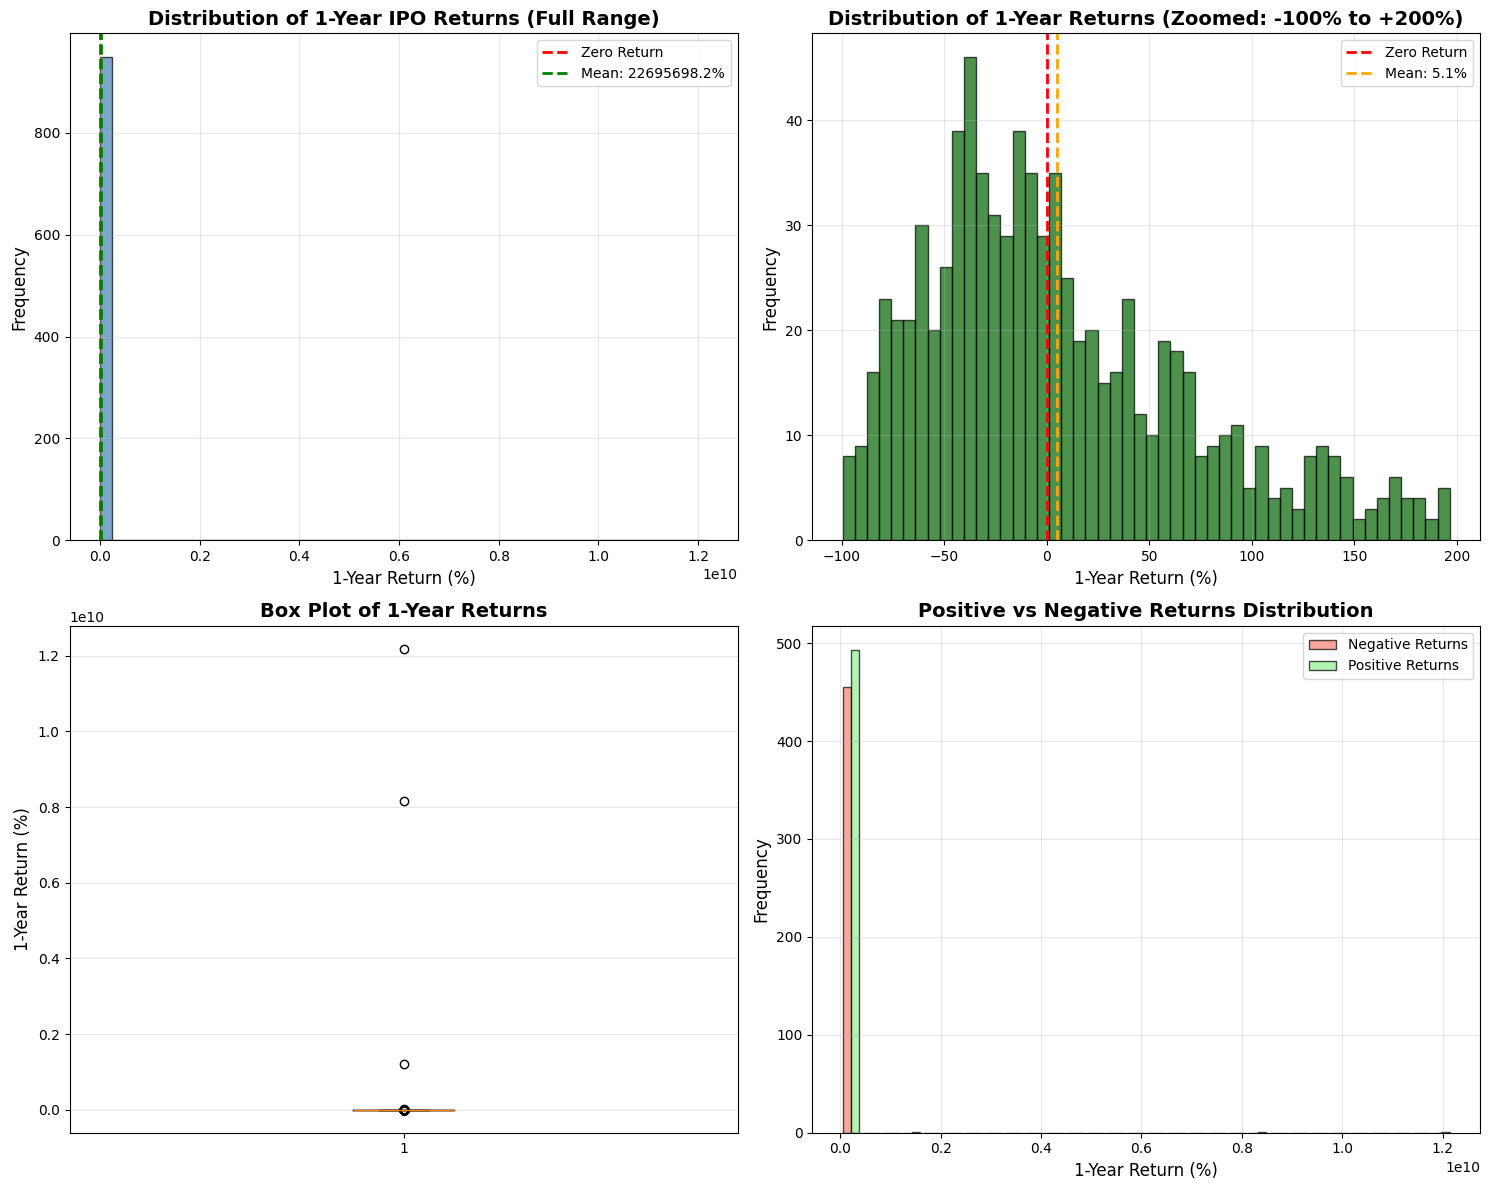

✓ Saved: 1st_day_vs_1year_comparison.png


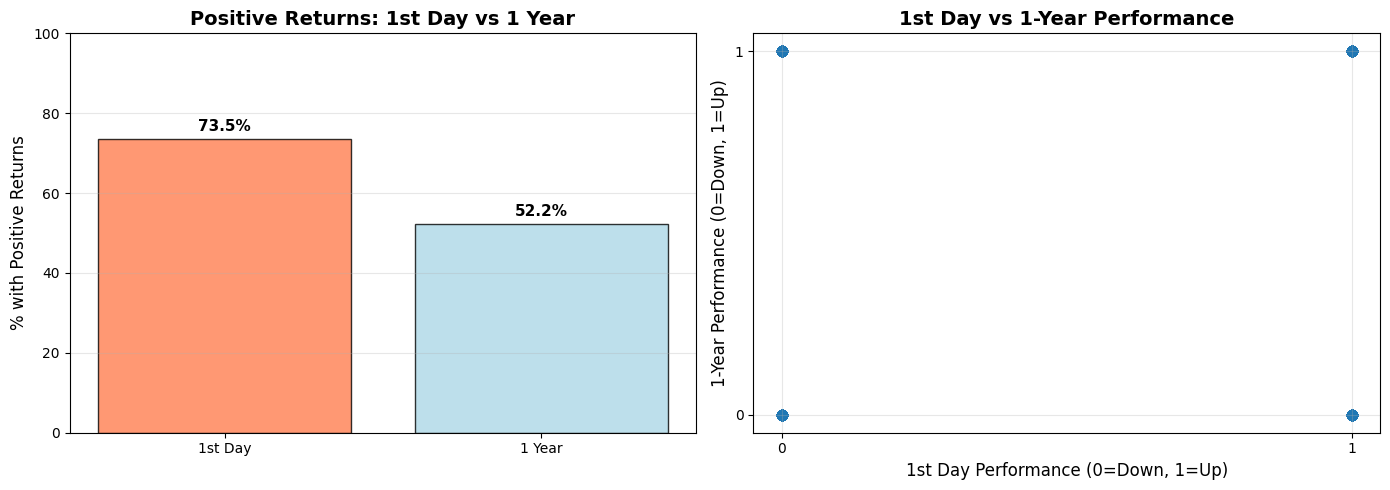

✓ Saved: top_bottom_performers.png


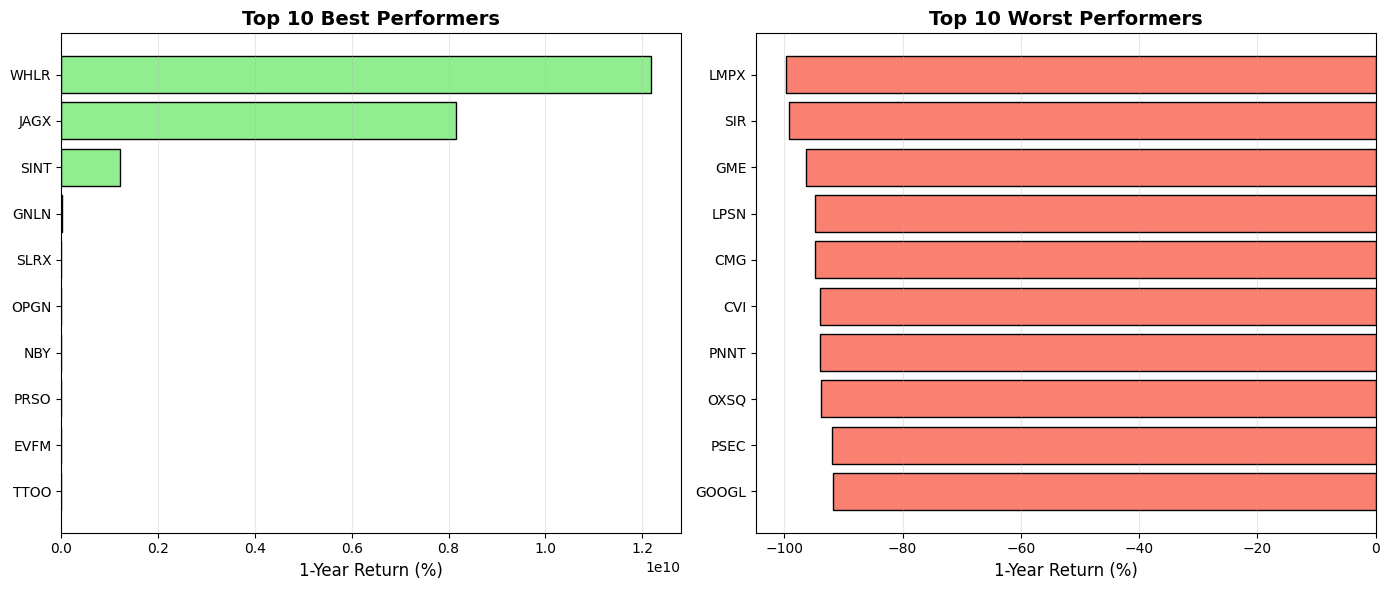


✅ All plots created!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load your data
df = pd.read_csv('data_with_1year_returns_FINAL.csv')

# Get only successful returns
completed = df[df['status'] == 'success'].copy()

print(f"Total IPOs with 1-year return data: {len(completed)}")
print(f"Positive returns: {(completed['1_year_up']==1).sum()} ({(completed['1_year_up']==1).mean()*100:.1f}%)")
print(f"Negative returns: {(completed['1_year_up']==0).sum()} ({(completed['1_year_up']==0).mean()*100:.1f}%)")
print(f"\nReturn Statistics:")
print(f"  Mean:   {completed['1_year_return'].mean():+.2f}%")
print(f"  Median: {completed['1_year_return'].median():+.2f}%")
print(f"  Std:    {completed['1_year_return'].std():.2f}%")
print(f"  Min:    {completed['1_year_return'].min():+.2f}%")
print(f"  Max:    {completed['1_year_return'].max():+.2f}%")

# ============================================================================
# PLOT 1: Histogram of Returns
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Full distribution
axes[0, 0].hist(completed['1_year_return'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Return')
axes[0, 0].axvline(x=completed['1_year_return'].mean(), color='green', linestyle='--', linewidth=2, label=f'Mean: {completed["1_year_return"].mean():.1f}%')
axes[0, 0].set_xlabel('1-Year Return (%)', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Distribution of 1-Year IPO Returns (Full Range)', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Zoomed distribution (-100% to +200%)
zoomed = completed[(completed['1_year_return'] >= -100) & (completed['1_year_return'] <= 200)]
axes[0, 1].hist(zoomed['1_year_return'], bins=50, color='darkgreen', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Return')
axes[0, 1].axvline(x=zoomed['1_year_return'].mean(), color='orange', linestyle='--', linewidth=2, label=f'Mean: {zoomed["1_year_return"].mean():.1f}%')
axes[0, 1].set_xlabel('1-Year Return (%)', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].set_title('Distribution of 1-Year Returns (Zoomed: -100% to +200%)', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Box plot
axes[1, 0].boxplot(completed['1_year_return'], vert=True)
axes[1, 0].set_ylabel('1-Year Return (%)', fontsize=12)
axes[1, 0].set_title('Box Plot of 1-Year Returns', fontsize=14, fontweight='bold')
axes[1, 0].grid(alpha=0.3, axis='y')

# 4. Positive vs Negative comparison
positive_returns = completed[completed['1_year_up'] == 1]['1_year_return']
negative_returns = completed[completed['1_year_up'] == 0]['1_year_return']

axes[1, 1].hist([negative_returns, positive_returns], bins=30, 
                label=['Negative Returns', 'Positive Returns'], 
                color=['salmon', 'lightgreen'], alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('1-Year Return (%)', fontsize=12)
axes[1, 1].set_ylabel('Frequency', fontsize=12)
axes[1, 1].set_title('Positive vs Negative Returns Distribution', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('1year_return_distribution.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: 1year_return_distribution.png")
plt.show()

# ============================================================================
# PLOT 2: Compare 1st Day vs 1-Year Returns
# ============================================================================

# Get IPOs that have both 1st day and 1-year data
both_data = completed[completed['Underpriced'].notna()].copy()

if len(both_data) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Compare percentages
    first_day_positive = (both_data['Underpriced'] == 1).sum()
    first_year_positive = (both_data['1_year_up'] == 1).sum()
    
    comparison = pd.DataFrame({
        'Period': ['1st Day', '1 Year'],
        'Positive (%)': [
            first_day_positive / len(both_data) * 100,
            first_year_positive / len(both_data) * 100
        ]
    })
    
    axes[0].bar(comparison['Period'], comparison['Positive (%)'], 
                color=['coral', 'lightblue'], alpha=0.8, edgecolor='black')
    axes[0].set_ylabel('% with Positive Returns', fontsize=12)
    axes[0].set_title('Positive Returns: 1st Day vs 1 Year', fontsize=14, fontweight='bold')
    axes[0].set_ylim([0, 100])
    axes[0].grid(alpha=0.3, axis='y')
    
    for i, v in enumerate(comparison['Positive (%)']):
        axes[0].text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')
    
    # Scatter plot
    axes[1].scatter(both_data['Underpriced'], both_data['1_year_up'], alpha=0.5, s=50)
    axes[1].set_xlabel('1st Day Performance (0=Down, 1=Up)', fontsize=12)
    axes[1].set_ylabel('1-Year Performance (0=Down, 1=Up)', fontsize=12)
    axes[1].set_title('1st Day vs 1-Year Performance', fontsize=14, fontweight='bold')
    axes[1].set_xticks([0, 1])
    axes[1].set_yticks([0, 1])
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('1st_day_vs_1year_comparison.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: 1st_day_vs_1year_comparison.png")
    plt.show()

# ============================================================================
# PLOT 3: Top/Bottom Performers
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 10 performers
top10 = completed.nlargest(10, '1_year_return')[['Issuer Ticker', '1_year_return']]
axes[0].barh(range(len(top10)), top10['1_year_return'], color='lightgreen', edgecolor='black')
axes[0].set_yticks(range(len(top10)))
axes[0].set_yticklabels(top10['Issuer Ticker'])
axes[0].invert_yaxis()
axes[0].set_xlabel('1-Year Return (%)', fontsize=12)
axes[0].set_title('Top 10 Best Performers', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3, axis='x')

# Bottom 10 performers
bottom10 = completed.nsmallest(10, '1_year_return')[['Issuer Ticker', '1_year_return']]
axes[1].barh(range(len(bottom10)), bottom10['1_year_return'], color='salmon', edgecolor='black')
axes[1].set_yticks(range(len(bottom10)))
axes[1].set_yticklabels(bottom10['Issuer Ticker'])
axes[1].invert_yaxis()
axes[1].set_xlabel('1-Year Return (%)', fontsize=12)
axes[1].set_title('Top 10 Worst Performers', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('top_bottom_performers.png', dpi=300, bbox_inches='tight')
print("✓ Saved: top_bottom_performers.png")
plt.show()

print("\n✅ All plots created!")

OUTLIER ANALYSIS - NO REMOVAL

Total IPOs with data: 951

Current Statistics:
  Mean:   +22695698.20%
  Median: +4.60%
  Std:    476669566.19%
  Min:    -99.76%
  Max:    +12182753423.81%

TOP 20 HIGHEST RETURNS (Potential Outliers)
     Issuer Ticker                     Issuer Name  Offer Price     price_1yr  1_year_return
1635          WHLR  Wheeler Real Estate Investment         5.25  6.395946e+08   1.218275e+10
820           JAGX               Jaguar Health Inc         7.00  5.705437e+08   8.150625e+09
1381          SINT          SiNtx Technologies Inc         5.75  7.020000e+07   1.220869e+09
663           GNLN          Greenlane Holdings Inc        17.00  3.069000e+06   1.805284e+07
1393          SLRX    Salarius Pharmaceuticals Inc        16.00  6.240000e+05   3.899900e+06
1123          OPGN                       OpGen Inc         6.00  1.244000e+05   2.073233e+06
1036           NBY     NovaBay Pharmaceuticals Inc         4.00  3.987998e+04   9.968994e+05
1216          PRSO     

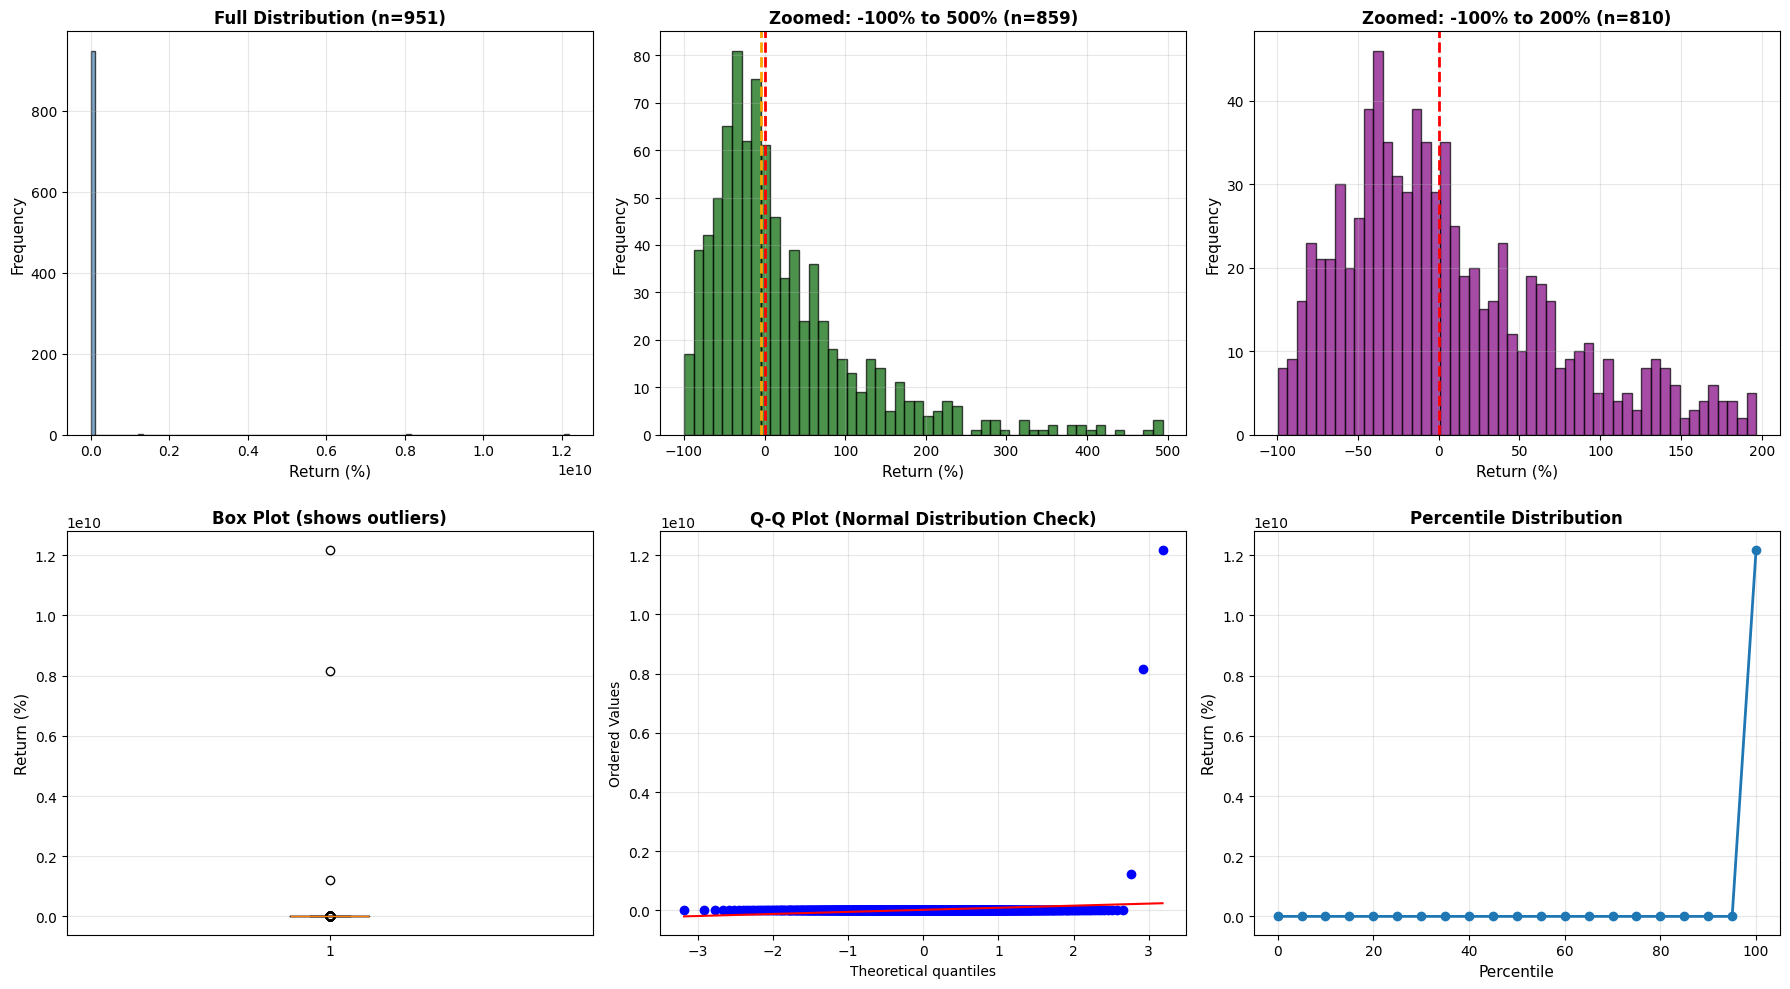


RECOMMENDATION

Based on the median (4.60%) vs mean (22695698.20%),
the data is HEAVILY skewed by extreme outliers.

Most robust approach: Use Percentile Method or IQR Method
Suggested range for ML: -100% to +1000% (removes 70 outliers)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('data_with_1year_returns_FINAL.csv')
completed = df[df['status'] == 'success'].copy()

print("="*80)
print("OUTLIER ANALYSIS - NO REMOVAL")
print("="*80 + "\n")

print(f"Total IPOs with data: {len(completed)}\n")

# Basic stats
print("Current Statistics:")
print(f"  Mean:   {completed['1_year_return'].mean():+.2f}%")
print(f"  Median: {completed['1_year_return'].median():+.2f}%")
print(f"  Std:    {completed['1_year_return'].std():.2f}%")
print(f"  Min:    {completed['1_year_return'].min():+.2f}%")
print(f"  Max:    {completed['1_year_return'].max():+.2f}%")

# ============================================================================
# Show extreme values
# ============================================================================

print("\n" + "="*80)
print("TOP 20 HIGHEST RETURNS (Potential Outliers)")
print("="*80)
extreme_high = completed.nlargest(20, '1_year_return')[['Issuer Ticker', 'Issuer Name', 'Offer Price', 'price_1yr', '1_year_return']]
print(extreme_high.to_string())

print("\n" + "="*80)
print("TOP 20 LOWEST RETURNS (Potential Outliers)")
print("="*80)
extreme_low = completed.nsmallest(20, '1_year_return')[['Issuer Ticker', 'Issuer Name', 'Offer Price', 'price_1yr', '1_year_return']]
print(extreme_low.to_string())

# ============================================================================
# Different outlier detection methods
# ============================================================================

print("\n" + "="*80)
print("OUTLIER DETECTION METHODS")
print("="*80 + "\n")

# Method 1: IQR
Q1 = completed['1_year_return'].quantile(0.25)
Q3 = completed['1_year_return'].quantile(0.75)
IQR = Q3 - Q1
lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR

outliers_iqr = completed[(completed['1_year_return'] < lower_iqr) | 
                          (completed['1_year_return'] > upper_iqr)]

print(f"1. IQR Method (1.5 * IQR):")
print(f"   Lower bound: {lower_iqr:.2f}%")
print(f"   Upper bound: {upper_iqr:.2f}%")
print(f"   Outliers: {len(outliers_iqr)} ({len(outliers_iqr)/len(completed)*100:.1f}%)")

# Method 2: Z-score
mean = completed['1_year_return'].mean()
std = completed['1_year_return'].std()
z_scores = np.abs((completed['1_year_return'] - mean) / std)
outliers_z3 = completed[z_scores > 3]
outliers_z2 = completed[z_scores > 2]

print(f"\n2. Z-Score Method:")
print(f"   |Z| > 3: {len(outliers_z3)} outliers ({len(outliers_z3)/len(completed)*100:.1f}%)")
print(f"   |Z| > 2: {len(outliers_z2)} outliers ({len(outliers_z2)/len(completed)*100:.1f}%)")

# Method 3: Percentile-based
p1 = completed['1_year_return'].quantile(0.01)
p99 = completed['1_year_return'].quantile(0.99)
outliers_percentile = completed[(completed['1_year_return'] < p1) | 
                                 (completed['1_year_return'] > p99)]

print(f"\n3. Percentile Method (1st and 99th percentile):")
print(f"   1st percentile: {p1:.2f}%")
print(f"   99th percentile: {p99:.2f}%")
print(f"   Outliers: {len(outliers_percentile)} ({len(outliers_percentile)/len(completed)*100:.1f}%)")

# Method 4: Manual reasonable ranges
ranges = [
    (-100, 500, "Conservative"),
    (-100, 1000, "Moderate"),
    (-100, 2000, "Liberal"),
    (-100, 5000, "Very Liberal")
]

print(f"\n4. Manual Range Methods:")
for min_r, max_r, label in ranges:
    within_range = completed[(completed['1_year_return'] >= min_r) & 
                             (completed['1_year_return'] <= max_r)]
    outliers_count = len(completed) - len(within_range)
    print(f"   {label} ({min_r}% to {max_r}%): {outliers_count} outliers ({outliers_count/len(completed)*100:.1f}%)")

# ============================================================================
# Visualize distributions
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Full histogram
axes[0, 0].hist(completed['1_year_return'], bins=100, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Return (%)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title(f'Full Distribution (n={len(completed)})', fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# 2. Zoomed: -100 to 500%
zoom1 = completed[(completed['1_year_return'] >= -100) & (completed['1_year_return'] <= 500)]
axes[0, 1].hist(zoom1['1_year_return'], bins=50, color='darkgreen', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].axvline(x=zoom1['1_year_return'].median(), color='orange', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Return (%)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title(f'Zoomed: -100% to 500% (n={len(zoom1)})', fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# 3. Zoomed: -100 to 200%
zoom2 = completed[(completed['1_year_return'] >= -100) & (completed['1_year_return'] <= 200)]
axes[0, 2].hist(zoom2['1_year_return'], bins=50, color='purple', alpha=0.7, edgecolor='black')
axes[0, 2].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 2].set_xlabel('Return (%)', fontsize=11)
axes[0, 2].set_ylabel('Frequency', fontsize=11)
axes[0, 2].set_title(f'Zoomed: -100% to 200% (n={len(zoom2)})', fontweight='bold')
axes[0, 2].grid(alpha=0.3)

# 4. Box plot
axes[1, 0].boxplot(completed['1_year_return'], vert=True)
axes[1, 0].set_ylabel('Return (%)', fontsize=11)
axes[1, 0].set_title('Box Plot (shows outliers)', fontweight='bold')
axes[1, 0].grid(alpha=0.3, axis='y')

# 5. Q-Q plot (check normality)
from scipy import stats
stats.probplot(completed['1_year_return'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Normal Distribution Check)', fontweight='bold')
axes[1, 1].grid(alpha=0.3)

# 6. Percentile distribution
percentiles = np.percentile(completed['1_year_return'], range(0, 101, 5))
axes[1, 2].plot(range(0, 101, 5), percentiles, marker='o', linewidth=2, markersize=6)
axes[1, 2].set_xlabel('Percentile', fontsize=11)
axes[1, 2].set_ylabel('Return (%)', fontsize=11)
axes[1, 2].set_title('Percentile Distribution', fontweight='bold')
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outlier_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: outlier_analysis.png")
plt.show()

print("\n" + "="*80)
print("RECOMMENDATION")
print("="*80)
print(f"\nBased on the median ({completed['1_year_return'].median():.2f}%) vs mean ({completed['1_year_return'].mean():.2f}%),")
print("the data is HEAVILY skewed by extreme outliers.")
print(f"\nMost robust approach: Use Percentile Method or IQR Method")
print(f"Suggested range for ML: -100% to +1000% (removes {len(completed) - len(completed[(completed['1_year_return'] >= -100) & (completed['1_year_return'] <= 1000)])} outliers)")